In [47]:
import pandas as pd
import numpy as np
from pathlib import Path

##  Step 1: Imports and data path

In [34]:
DATA_DIR = Path("../../../data/raw/Yashaswi/AQI/AllPollutantsHourly/")

## Step 2: Correct reader for YOUR NAPS files

In [35]:
def read_naps_csv(path):
    df = pd.read_csv(
        path,
        skiprows=7,
        sep=",",
        engine="python",        # ← more tolerant parser
        on_bad_lines="skip"     # ← skip malformed rows safely

    )

    # Clean bilingual column names
    df.columns = [c.split("//")[0].strip() for c in df.columns]

    # Normalize names we will use downstream
    df = df.rename(columns={
        "Province/Territory": "Province"
    })

    return df


In [36]:

df_test = read_naps_csv(DATA_DIR / "SO2_2024.csv")
print(df_test.columns)
print(df_test.head())


Index(['Pollutant', 'NAPS ID', 'City', 'Province', 'Latitude', 'Longitude',
       'Date', 'H01', 'H02', 'H03', 'H04', 'H05', 'H06', 'H07', 'H08', 'H09',
       'H10', 'H11', 'H12', 'H13', 'H14', 'H15', 'H16', 'H17', 'H18', 'H19',
       'H20', 'H21', 'H22', 'H23', 'H24'],
      dtype='str')
  Pollutant  NAPS ID        City Province  Latitude  Longitude        Date  \
0       SO2    10102  St. John's       NL  47.56038  -52.71147  2024-01-01   
1       SO2    10102  St. John's       NL  47.56038  -52.71147  2024-01-02   
2       SO2    10102  St. John's       NL  47.56038  -52.71147  2024-01-03   
3       SO2    10102  St. John's       NL  47.56038  -52.71147  2024-01-04   
4       SO2    10102  St. John's       NL  47.56038  -52.71147  2024-01-05   

   H01  H02  H03  ...  H15  H16  H17  H18  H19  H20  H21  H22  H23  H24  
0  0.0  0.0  0.0  ...  0.0  0.1  0.1  0.1  0.1  0.1  0.1  0.2  0.1  0.2  
1  0.1  0.0  0.0  ...  0.1  0.0  0.1  0.1  0.1  0.1  0.2  0.1  0.1  0.1  
2  0.1  0.0  0.0

##  Step 3: Reshape hourly → long format

In [37]:
def reshape_hourly(df):
    # Normalize pollutant naming
    df["Pollutant"] = (
        df["Pollutant"]
        .replace({"PM25": "PM2.5"})
        .astype(str)
    )

    # Ignore NO and NOX
    if df["Pollutant"].iloc[0] in {"NO", "NOX"}:
        return None

    hour_cols = [c for c in df.columns if c.startswith("H")]

    df_long = df.melt(
        id_vars=[
            "Pollutant",
            "NAPS ID",
            "City",
            "Province",
            "Latitude",
            "Longitude",
            "Date",
        ],
        value_vars=hour_cols,
        var_name="Hour",
        value_name="Concentration",
    )

    df_long["Hour"] = df_long["Hour"].str.replace("H", "").astype(int) - 1
    df_long["Datetime"] = (
        pd.to_datetime(df_long["Date"])
        + pd.to_timedelta(df_long["Hour"], unit="h")
    )

    df_long.loc[df_long["Concentration"] == -999, "Concentration"] = np.nan

    return df_long

## Step 4: Unit conversion (O₃ only)

In [38]:
def apply_units(df):
    if df["Pollutant"].iloc[0] == "O3":
        # O₃ is in ppb → convert to ppm for EPA AQI
        df["Concentration"] = df["Concentration"] / 1000.0
    return df

## Step 5: Daily AQI concentration metric

In [39]:
def daily_metric(df):
    pol = df["Pollutant"].iloc[0]
    g = df.groupby(["NAPS ID", df["Datetime"].dt.date])

    if pol in {"O3", "CO"}:
        # Daily max 8‑hour rolling average
        return (
            g.apply(
                lambda x: x.set_index("Datetime")["Concentration"]
                .rolling(8, min_periods=6)
                .mean()
                .max()
            )
            .rename("C")
            .reset_index()
        )

    if pol in {"NO2", "SO2"}:
        # Daily max 1‑hour
        return g["Concentration"].max().reset_index(name="C")

    if pol in {"PM10", "PM2.5"}:
        # 24‑hour mean
        return g["Concentration"].mean().reset_index(name="C")

## Step 6: EPA AQI breakpoints

In [40]:
AQI_BREAKPOINTS = {
    "O3": [
        (0.000, 0.054, 0, 50),
        (0.055, 0.070, 51, 100),
        (0.071, 0.085, 101, 150),
        (0.086, 0.105, 151, 200),
        (0.106, 0.200, 201, 300),
    ],
    "PM2.5": [
        (0.0, 9.0, 0, 50),
        (9.1, 35.4, 51, 100),
        (35.5, 55.4, 101, 150),
        (55.5, 125.4, 151, 200),
        (125.5, 225.4, 201, 300),
    ],
    "PM10": [
        (0, 54, 0, 50),
        (55, 154, 51, 100),
        (155, 254, 101, 150),
        (255, 354, 151, 200),
        (355, 424, 201, 300),
    ],
    "CO": [
        (0.0, 4.4, 0, 50),
        (4.5, 9.4, 51, 100),
        (9.5, 12.4, 101, 150),
        (12.5, 15.4, 151, 200),
        (15.5, 30.4, 201, 300),
    ],
    "NO2": [
        (0, 53, 0, 50),
        (54, 100, 51, 100),
        (101, 360, 101, 150),
        (361, 649, 151, 200),
        (650, 1249, 201, 300),
    ],
    "SO2": [
        (0, 35, 0, 50),
        (36, 75, 51, 100),
        (76, 185, 101, 150),
        (186, 304, 151, 200),
        (305, 604, 201, 300),
    ],
}

## Step 7: AQI calculation

## Truncate concentrations BEFORE compute_aqi

In [41]:
def truncate_concentration(C, pollutant):
    """
    Truncate concentration values according to EPA AQI rules.
    Truncation means cutting off decimals WITHOUT rounding.
    """
    if pd.isna(C):
        return np.nan

    if pollutant == "O3":        # ppm → 3 decimals
        return np.floor(C * 1000) / 1000

    if pollutant == "PM2.5":     # µg/m3 → 1 decimal
        return np.floor(C * 10) / 10

    if pollutant == "PM10":      # µg/m3 → integer
        return np.floor(C)

    if pollutant == "CO":        # ppm → 1 decimal
        return np.floor(C * 10) / 10

    if pollutant in {"SO2", "NO2"}:  # ppb → integer
        return np.floor(C)

    return np.nan

In [42]:
def compute_aqi(C, pollutant):
    if pd.isna(C):
        return np.nan

    for c_lo, c_hi, aqi_lo, aqi_hi in AQI_BREAKPOINTS[pollutant]:
        if c_lo <= C <= c_hi:
            return round(
                (aqi_hi - aqi_lo)
                / (c_hi - c_lo)
                * (C - c_lo)
                + aqi_lo
            )

    return np.nan

## Quick test 

In [43]:
print(compute_aqi(0.060, "O3"))     # Should be Moderate (~67)
print(compute_aqi(35.0, "PM2.5"))  # Should be ~100
print(compute_aqi(8.0, "CO"))      # Should be Moderate

67
99
86


## Calculate AQI for 2010 to 2024

In [44]:
YEARS = range(2010, 2025)

POLLUTANTS = [
    "O3",
    "NO2",
    "CO",
    "PM25",
    "PM10",
    "SO2",
]

aqi_by_year = {}

In [48]:
for year in YEARS:
    print(f"\nProcessing year {year}")
    daily_results = []

    for pol in POLLUTANTS:
        fname = f"{pol}_{year}.csv"
        print(f"  Processing {fname}")

        df_raw = read_naps_csv(DATA_DIR / fname)
        df_long = reshape_hourly(df_raw)

        if df_long is None:
            continue

        df_long = apply_units(df_long)
        daily = daily_metric(df_long)

        pollutant = df_long["Pollutant"].iloc[0]
        daily["Pollutant"] = pollutant

        # AQI computation (expects EPA-truncated C if you added that earlier)
        daily["AQI"] = daily["C"].apply(
            lambda x: compute_aqi(x, pollutant)
        )

        daily["Year"] = year
        daily_results.append(daily)

    # Combine all pollutants for the year
    if daily_results:
        aqi_by_year[year] = pd.concat(
            daily_results, ignore_index=True
        )


Processing year 2010
  Processing O3_2010.csv
  Processing NO2_2010.csv
  Processing CO_2010.csv
  Processing PM25_2010.csv
  Processing PM10_2010.csv
  Processing SO2_2010.csv

Processing year 2011
  Processing O3_2011.csv
  Processing NO2_2011.csv
  Processing CO_2011.csv
  Processing PM25_2011.csv
  Processing PM10_2011.csv
  Processing SO2_2011.csv

Processing year 2012
  Processing O3_2012.csv
  Processing NO2_2012.csv
  Processing CO_2012.csv
  Processing PM25_2012.csv
  Processing PM10_2012.csv
  Processing SO2_2012.csv

Processing year 2013
  Processing O3_2013.csv
  Processing NO2_2013.csv
  Processing CO_2013.csv
  Processing PM25_2013.csv
  Processing PM10_2013.csv
  Processing SO2_2013.csv

Processing year 2014
  Processing O3_2014.csv
  Processing NO2_2014.csv
  Processing CO_2014.csv
  Processing PM25_2014.csv
  Processing PM10_2014.csv
  Processing SO2_2014.csv

Processing year 2015
  Processing O3_2015.csv
  Processing NO2_2015.csv
  Processing CO_2015.csv
  Processing

In [49]:
for year, df in aqi_by_year.items():
    if "Date" not in df.columns:
        df["Date"] = pd.to_datetime(df["Datetime"]).dt.date

In [50]:
def enforce_one_naps_per_day(df):
    return (
        df.groupby(
            ["NAPS ID", "Date", "Pollutant", "Year"],
            as_index=False
        )
        .agg({
            "C": "max",
            "AQI": "max"
        })
    )
    
def drop_nan_days(df):
    return df.dropna(subset=["AQI"])

In [51]:
print(aqi_by_year[2023].columns)

Index(['NAPS ID', 'Datetime', 'C', 'Pollutant', 'AQI', 'Year', 'Date'], dtype='str')


## Build one table per pollutant (2010–2024)

In [52]:

pollutant_tables = {}

for year, df_year in aqi_by_year.items():
    for pollutant, df_pol in df_year.groupby("Pollutant"):

        df_pol = enforce_one_naps_per_day(df_pol)
        df_pol = drop_nan_days(df_pol)

        pollutant_tables.setdefault(pollutant, []).append(df_pol)

for pollutant, dfs in pollutant_tables.items():
    final_df = pd.concat(dfs, ignore_index=True)

    out_file = DATA_DIR / f"AQI_{pollutant}_2010_2024.csv"
    final_df.to_csv(out_file, index=False)

    print(f"✅ Saved {pollutant}: {final_df.shape[0]} rows")


✅ Saved CO: 337233 rows
✅ Saved NO2: 962825 rows
✅ Saved O3: 1168903 rows
✅ Saved PM10: 209312 rows
✅ Saved PM2.5: 1125261 rows
✅ Saved SO2: 738170 rows


In [92]:

null_counts = final_df.isna().sum()

print(f"\n🔍 Null counts for {pollutant}:")
print(null_counts)
print(f"Total NULL cells: {null_counts.sum()}")



🔍 Null counts for SO2:
NAPS ID      0
Date         0
Pollutant    0
Year         0
C            0
AQI          0
dtype: int64
Total NULL cells: 0


In [111]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../../../data/raw/Yashaswi/AQI/AllPollutantsHourly")

dfs = []
for fname in DATA_DIR.glob("AQI_*_2010_2024.csv"):
    df = pd.read_csv(fname)
    dfs.append(df)

all_pollutants_df = pd.concat(dfs, ignore_index=True)
all_pollutants_df.head()

,NAPS ID,Date,Pollutant,Year,C,AQI
0,10102,2010-01-01,CO,2010,0.34625,4.0
1,10102,2010-01-02,CO,2010,0.46000,5.0
2,10102,2010-01-03,CO,2010,0.29500,3.0
3,10102,2010-01-04,CO,2010,0.23125,3.0
4,10102,2010-01-05,CO,2010,0.28000,3.0


In [150]:
all_pollutants_df["Pollutant"].value_counts()

Pollutant
O3       1168903
PM2.5    1125261
NO2       962825
SO2       738170
CO        337233
PM10      209312
Name: count, dtype: int64

## Filter 2014 to 2024 only

In [151]:
filtered_df = all_pollutants_df[
    (all_pollutants_df["Year"] >= 2015) &
    (all_pollutants_df["Year"] <= 2024)
]
filtered_df.head()

,NAPS ID,Date,Pollutant,Year,C,AQI
114227,10102,2015-01-01,CO,2015,0.19500,2.0
114228,10102,2015-01-02,CO,2015,0.17750,2.0
114229,10102,2015-01-03,CO,2015,0.17000,2.0
114230,10102,2015-01-04,CO,2015,0.17750,2.0
114231,10102,2015-01-05,CO,2015,0.16875,2.0


In [152]:
df = filtered_df.copy()
df["Date"] = pd.to_datetime(df["Date"])

In [153]:
df["Station_AQI"] = df.groupby(
    ["NAPS ID", "Date"]
)["AQI"].transform("max")

In [154]:
dominant_map = df.loc[
    df.groupby(["NAPS ID", "Date"])["AQI"].idxmax(),
    ["NAPS ID", "Date", "Pollutant"]
].rename(columns={"Pollutant": "Dominant_Pollutant"})


In [155]:
df = df.drop(columns=["Dominant_Pollutant"], errors="ignore")

In [156]:
df = df.merge(
    dominant_map,
    on=["NAPS ID", "Date"],
    how="left"
)
df.head()

,NAPS ID,Date,Pollutant,Year,C,AQI,Station_AQI,Dominant_Pollutant
0,10102,2015-01-01,CO,2015,0.19500,2.0,33.0,O3
1,10102,2015-01-02,CO,2015,0.17750,2.0,31.0,O3
2,10102,2015-01-03,CO,2015,0.17000,2.0,32.0,O3
3,10102,2015-01-04,CO,2015,0.17750,2.0,34.0,O3
4,10102,2015-01-05,CO,2015,0.16875,2.0,35.0,O3


In [157]:
df.groupby(["NAPS ID", "Date"])["Dominant_Pollutant"].nunique().value_counts()

Dominant_Pollutant
1    982754
Name: count, dtype: int64

In [158]:
(df["AQI"] == df["Station_AQI"]).sum() / len(df)

np.float64(0.32185876608240904)

## check — NO row duplication

In [159]:
df.duplicated(subset=["NAPS ID", "Date", "Pollutant"]).sum()

np.int64(0)

## Dominant matches Station_AQI

In [160]:
dominant_rows = df[df["Pollutant"] == df["Dominant_Pollutant"]]

(dominant_rows["AQI"] == dominant_rows["Station_AQI"]).all()

np.True_

In [161]:
df.groupby("Pollutant")["AQI"].mean().sort_values(ascending=False)

Pollutant
PM2.5    32.762320
O3       30.272654
PM10     13.328442
NO2      13.219916
SO2       4.912797
CO        2.939168
Name: AQI, dtype: float64

In [162]:
df.head()

,NAPS ID,Date,Pollutant,Year,C,AQI,Station_AQI,Dominant_Pollutant
0,10102,2015-01-01,CO,2015,0.19500,2.0,33.0,O3
1,10102,2015-01-02,CO,2015,0.17750,2.0,31.0,O3
2,10102,2015-01-03,CO,2015,0.17000,2.0,32.0,O3
3,10102,2015-01-04,CO,2015,0.17750,2.0,34.0,O3
4,10102,2015-01-05,CO,2015,0.16875,2.0,35.0,O3


## Export AQI file

In [163]:
df = df.rename(columns={
    "NAPS ID": "NAPS_ID",
    "C": "Pollutant Concentration"
})
df = df.drop(columns=["Year"])


In [164]:
df = df[
    [
        "NAPS_ID",
        "Date",
        "Pollutant",
        "Pollutant Concentration",
        "AQI",
        "Station_AQI",
        "Dominant_Pollutant"
    ]
]


In [169]:
df["Pollutant"] = df["Pollutant"].astype("category")
df["Dominant_Pollutant"] = df["Dominant_Pollutant"].astype("category")
df["AQI"] = df["AQI"].astype("float32")
df["Station_AQI"] = df["Station_AQI"].astype("float32")
df["Pollutant Concentration"] = df["Pollutant Concentration"].astype("float32")
df["Pollutant Concentration"] = df["Pollutant Concentration"].round(3)

In [170]:
df.head()

,NAPS_ID,Date,Pollutant,Pollutant Concentration,AQI,Station_AQI,Dominant_Pollutant
0,10102,2015-01-01,CO,0.195,2.0,33.0,O3
1,10102,2015-01-02,CO,0.178,2.0,31.0,O3
2,10102,2015-01-03,CO,0.170,2.0,32.0,O3
3,10102,2015-01-04,CO,0.178,2.0,34.0,O3
4,10102,2015-01-05,CO,0.169,2.0,35.0,O3


In [171]:
output_path = "../../../data/clean/Yashaswi/Final_Clean/AQI_2015_2024_FINAL.parquet"

In [172]:
df.to_parquet(output_path, engine="pyarrow", index=False)

## Calculate Consolidated AQI per day

In [173]:
df.head(3)

,NAPS_ID,Date,Pollutant,Pollutant Concentration,AQI,Station_AQI,Dominant_Pollutant
0,10102,2015-01-01,CO,0.195,2.0,33.0,O3
1,10102,2015-01-02,CO,0.178,2.0,31.0,O3
2,10102,2015-01-03,CO,0.170,2.0,32.0,O3


In [176]:
def compute_station_daily_aqi(df):

    df = df.dropna(subset=["AQI"])

    idx = df.groupby(["NAPS ID", "Date"])["AQI"].idxmax()

    station_daily_aqi = (
        df.loc[idx, ["NAPS ID", "Date", "AQI", "Pollutant"]]
        .rename(columns={"Pollutant": "Dominant_Pollutant"})
        .reset_index(drop=True)
    )

    return station_daily_aqi

In [178]:
station_daily_aqi = compute_station_daily_aqi(all_pollutants_df)
station_daily_aqi.head()

,NAPS ID,Date,AQI,Dominant_Pollutant
0,10102,2010-01-01,43.0,PM2.5
1,10102,2010-01-02,61.0,PM2.5
2,10102,2010-01-03,44.0,PM2.5
3,10102,2010-01-04,33.0,O3
4,10102,2010-01-05,30.0,PM2.5


In [179]:
station_daily_aqi["Dominant_Pollutant"].value_counts(normalize=True) * 100

Dominant_Pollutant
O3       46.350799
PM2.5    39.531662
SO2       6.710599
NO2       5.850744
PM10      1.503176
CO        0.053019
Name: proportion, dtype: float64

In [180]:
station_daily_aqi.head()

,NAPS ID,Date,AQI,Dominant_Pollutant
0,10102,2010-01-01,43.0,PM2.5
1,10102,2010-01-02,61.0,PM2.5
2,10102,2010-01-03,44.0,PM2.5
3,10102,2010-01-04,33.0,O3
4,10102,2010-01-05,30.0,PM2.5


In [181]:
station_daily_aqi.info()

<class 'pandas.DataFrame'>
RangeIndex: 1480598 entries, 0 to 1480597
Data columns (total 4 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   NAPS ID             1480598 non-null  int64  
 1   Date                1480598 non-null  str    
 2   AQI                 1480598 non-null  float64
 3   Dominant_Pollutant  1480598 non-null  str    
dtypes: float64(1), int64(1), str(2)
memory usage: 64.4 MB


In [182]:
station_daily_aqi["Dominant_Pollutant"].value_counts()

Dominant_Pollutant
O3       686269
PM2.5    585305
SO2       99357
NO2       86626
PM10      22256
CO          785
Name: count, dtype: int64

In [185]:
from pathlib import Path

OUTPUT_DIR = Path("../../../data/clean/Yashaswi/Final_Clean/")

# create folder if it doesn’t exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

out_file = OUTPUT_DIR / "AQI_2015_2024_new.parquet"

station_daily_aqi.to_parquet(out_file, index=False)

# Vizualization
## Step A — Prepare data for plotting
- We convert daily AQI → monthly mean AQI, then align by month (1–12).

In [64]:
import pandas as pd
import glob

files = glob.glob(str(DATA_DIR / "AQI_*_2010_2024.csv"))

dfs = []
for f in files:
    df = pd.read_csv(f)
    df["Date"] = pd.to_datetime(df["Date"])
    df["Year"] = df["Date"].dt.year
    df["DayOfYear"] = df["Date"].dt.dayofyear

    # Remove Feb 29 to align all years
    df = df[~((df["Date"].dt.month == 2) & (df["Date"].dt.day == 29))]

    dfs.append(df)

pollutant_df = pd.concat(dfs, ignore_index=True)

daily_pollutant = (
    pollutant_df
    .groupby(["Pollutant", "Year", "DayOfYear"], as_index=False)
    .agg(mean_AQI=("AQI", "mean"))
)

In [65]:
# daily_pollutant already exists: Pollutant, Year, DayOfYear, mean_AQI

daily_pollutant = daily_pollutant.sort_values(
    ["Pollutant", "Year", "DayOfYear"]
)

daily_pollutant["AQI_smooth"] = (
    daily_pollutant
    .groupby(["Pollutant", "Year"])["mean_AQI"]
    .transform(lambda x: x.rolling(30, center=True, min_periods=10).mean())
)


C:\Users\biauser\AppData\Local\Temp\ipykernel_11392\369664174.py:43: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\biauser\anaconda3\envs\ds312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


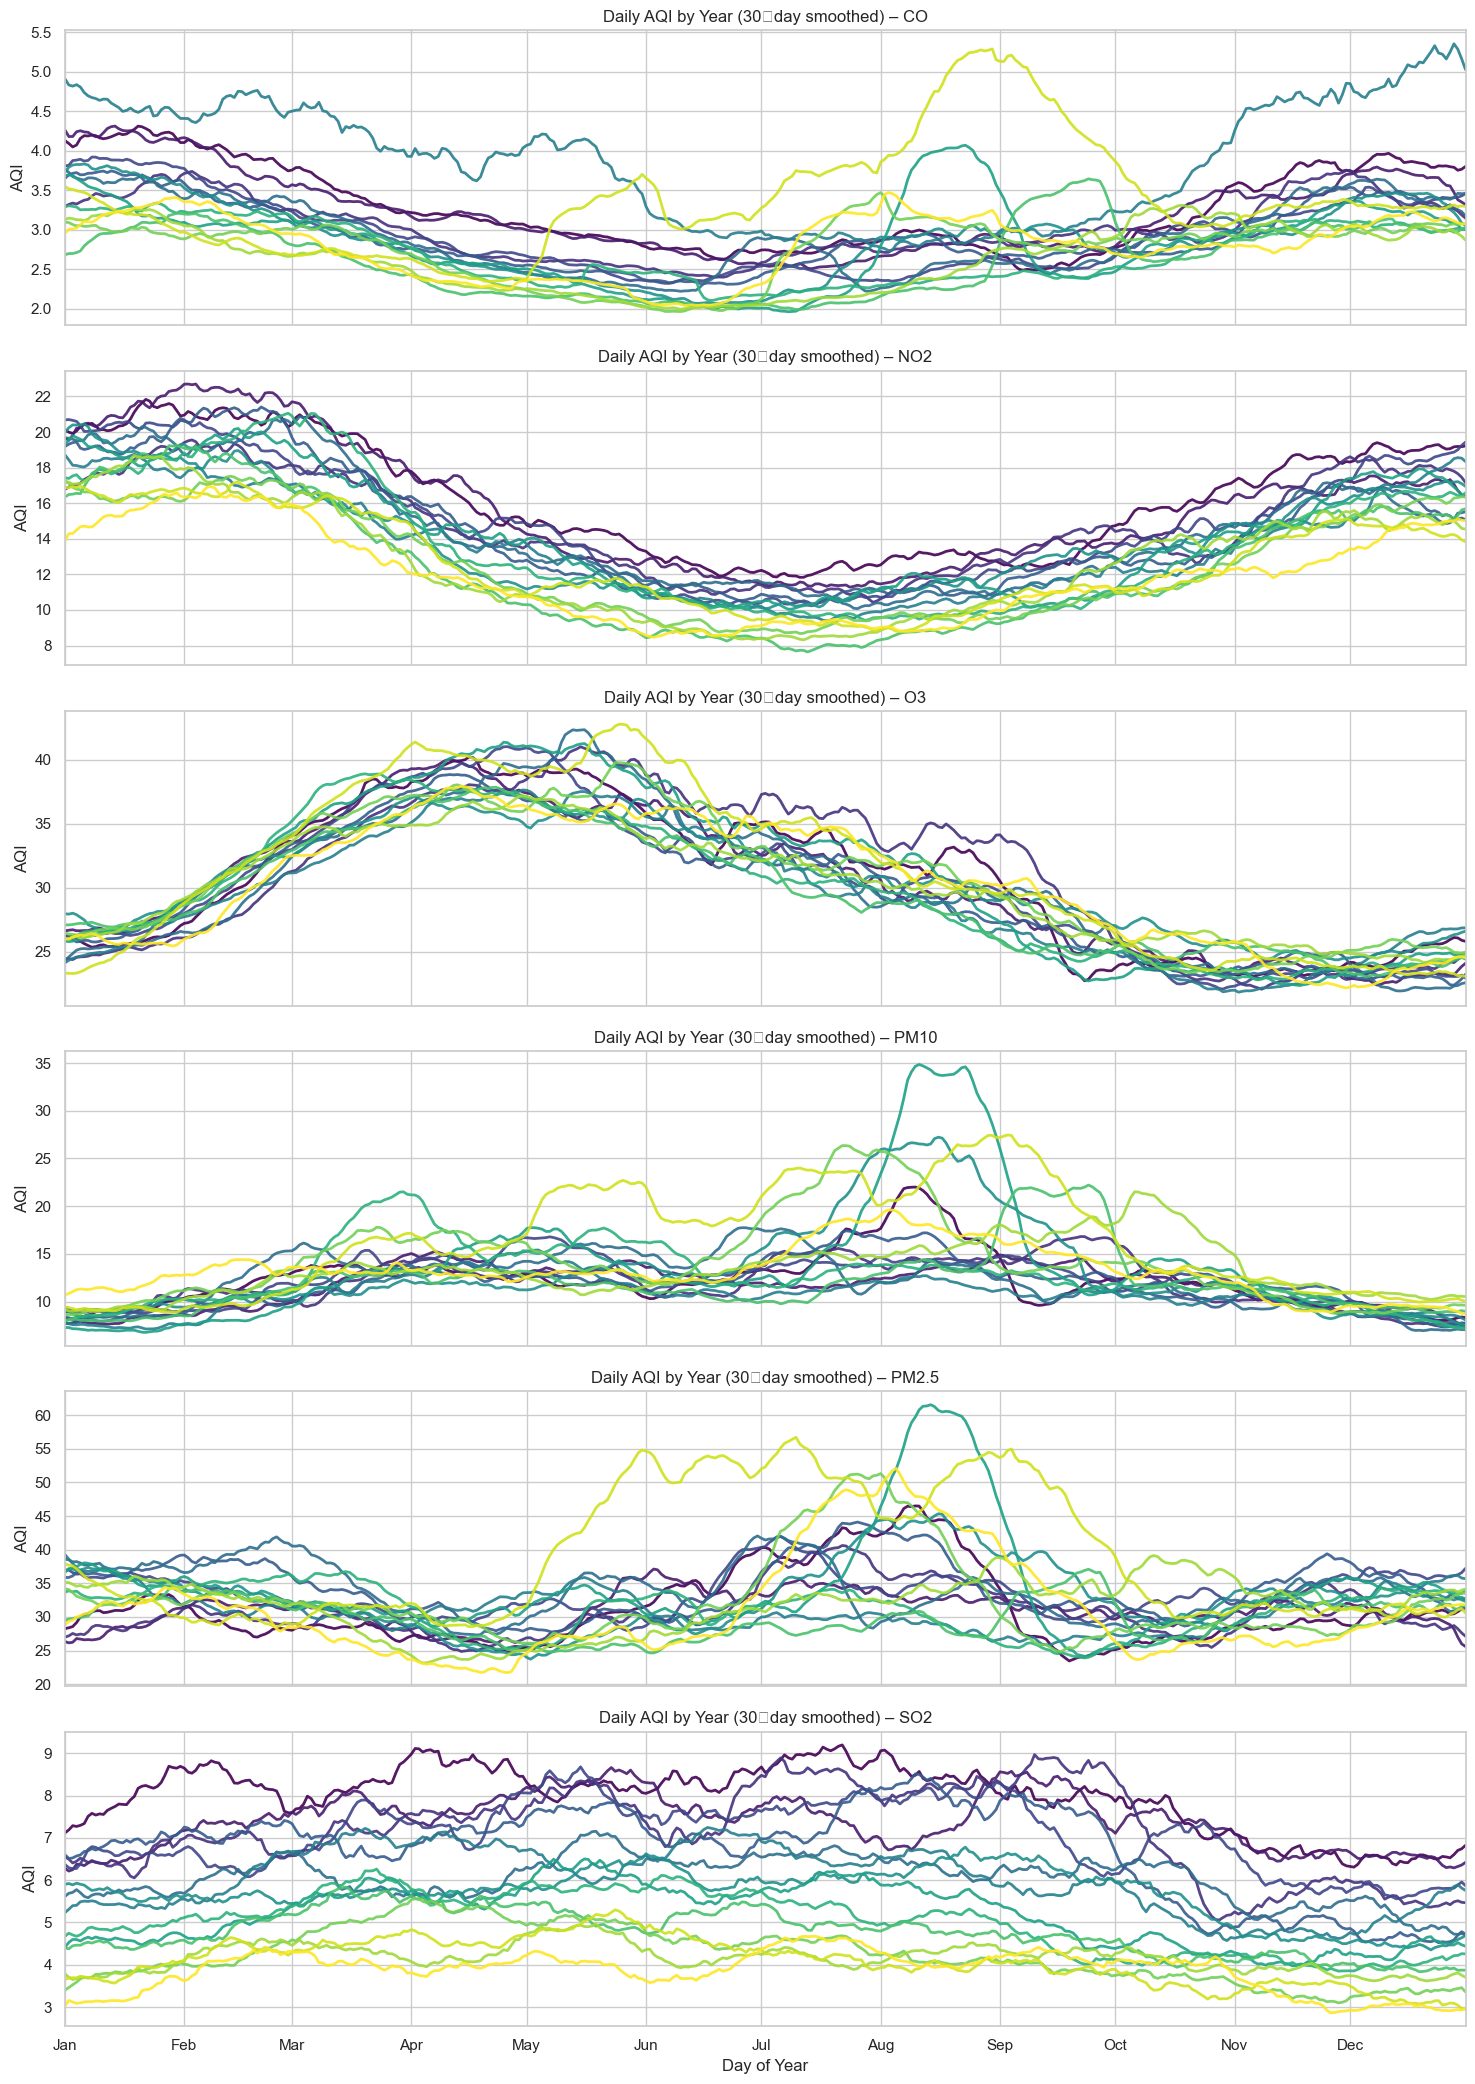

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt
month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

sns.set_theme(style="whitegrid")

pollutants = sorted(daily_pollutant["Pollutant"].unique())

fig, axes = plt.subplots(
    nrows=len(pollutants),
    ncols=1,
    figsize=(15, 3.5 * len(pollutants)),
    sharex=True
)

if len(pollutants) == 1:
    axes = [axes]

for ax, pol in zip(axes, pollutants):
    subset = daily_pollutant[daily_pollutant["Pollutant"] == pol]

    sns.lineplot(
        data=subset,
        x="DayOfYear",
        y="AQI_smooth",
        hue="Year",
        palette="viridis",
        linewidth=2,
        alpha=0.9,
        ax=ax,
        legend=False
    )

    ax.set_title(f"Daily AQI by Year (30‑day smoothed) – {pol}")
    ax.set_ylabel("AQI")
  
ax.set_xticks(month_starts)
ax.set_xticklabels(month_labels)
ax.set_xlim(1, 365)
axes[-1].set_xlabel("Day of Year")
plt.tight_layout()
plt.show()

## Multi‑panel time‑series plots last 5 years (one per pollutant)

In [67]:
print(daily_pollutant.columns)

Index(['Pollutant', 'Year', 'DayOfYear', 'mean_AQI', 'AQI_smooth'], dtype='str')


In [68]:
subset_2324 = daily_pollutant[
    daily_pollutant["Year"].isin([2020, 2021, 2022, 2023, 2024])
].copy()
month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

C:\Users\biauser\AppData\Local\Temp\ipykernel_11392\1272745492.py:40: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\biauser\anaconda3\envs\ds312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


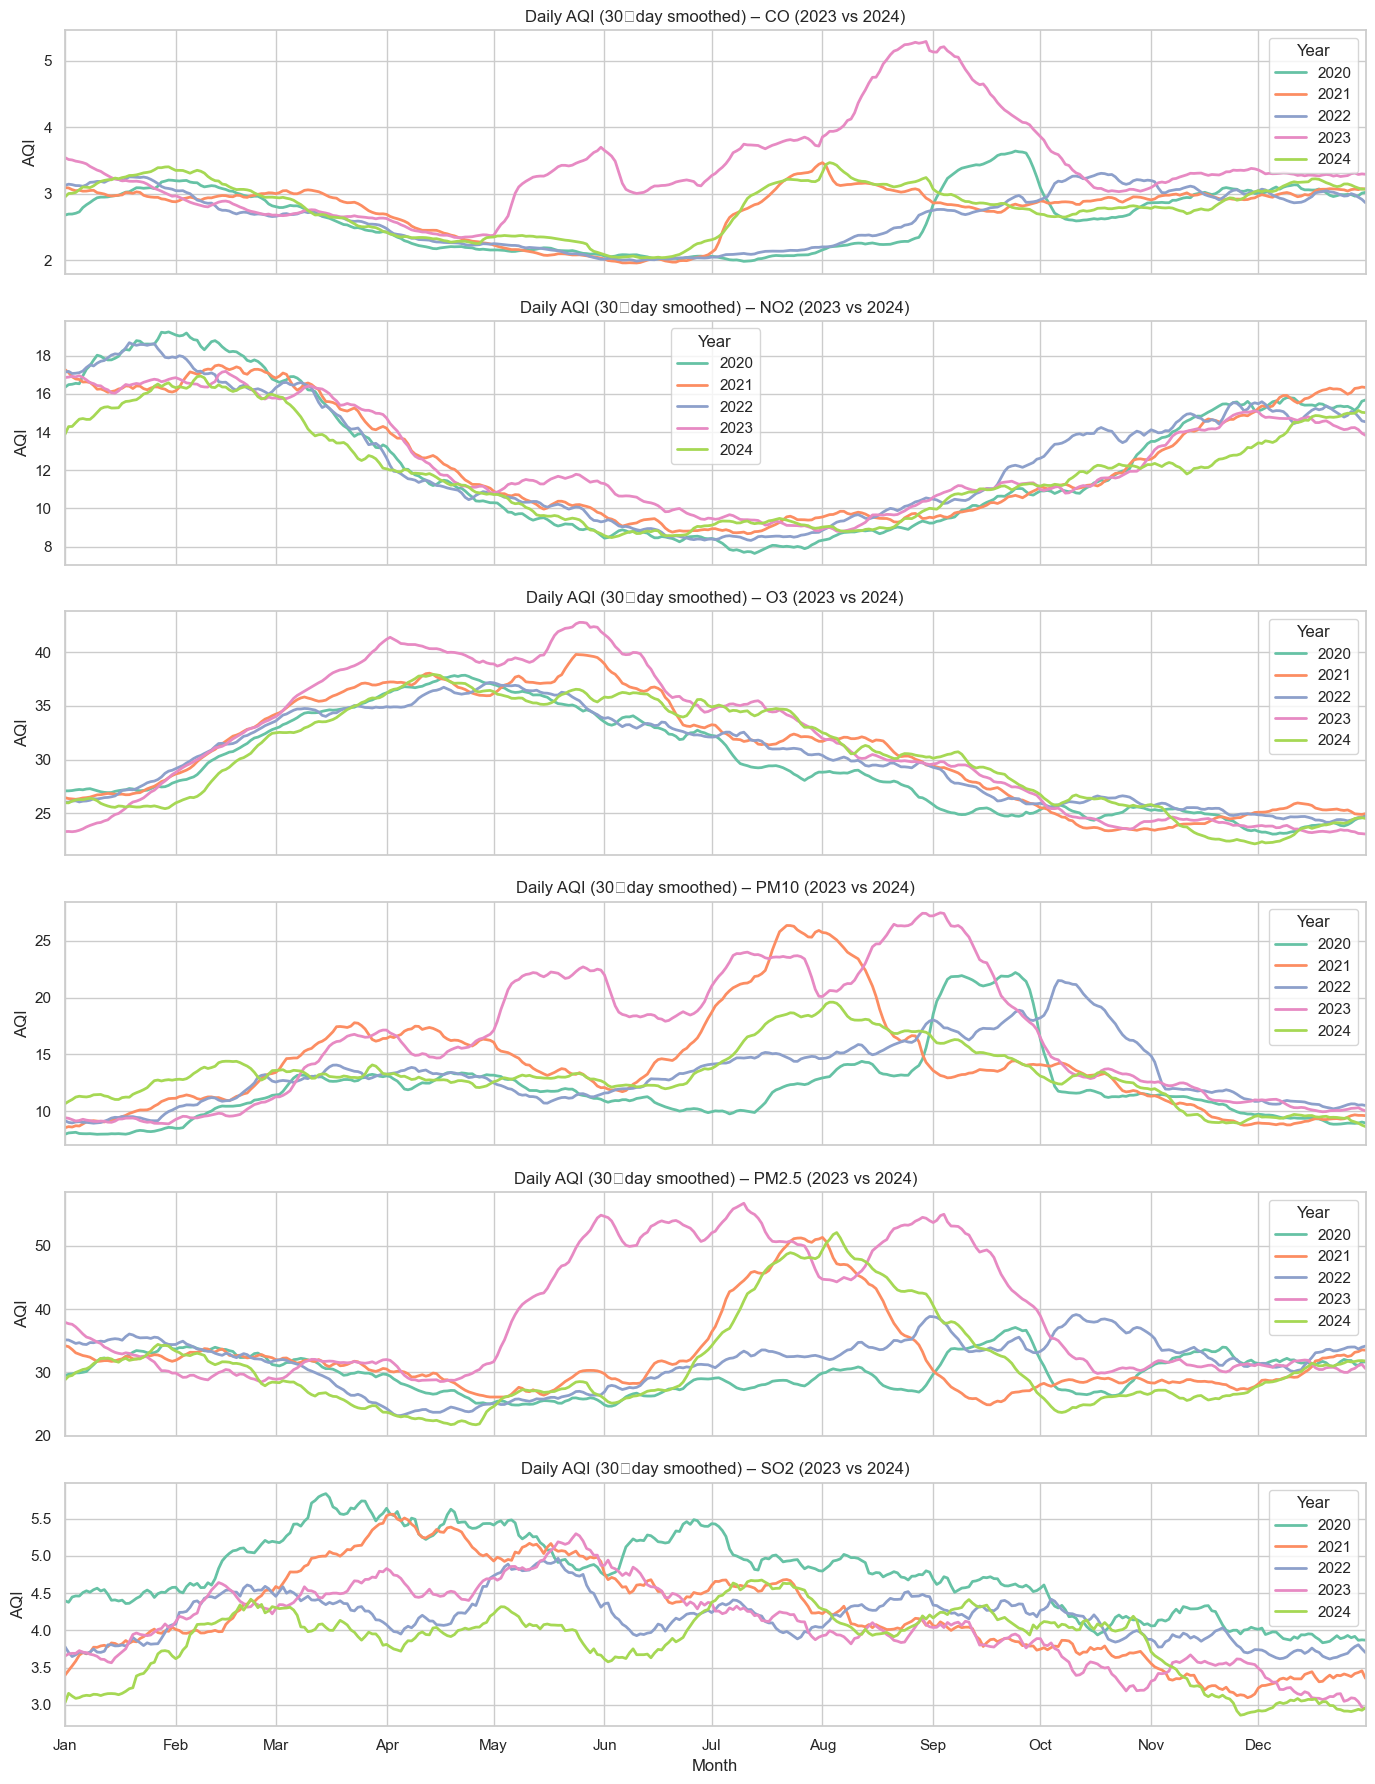

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

pollutants = sorted(subset_2324["Pollutant"].unique())
n_pollutants = len(pollutants)

fig, axes = plt.subplots(
    nrows=n_pollutants,
    ncols=1,
    figsize=(14, 3 * n_pollutants),
    sharex=True
)

if n_pollutants == 1:
    axes = [axes]

for ax, pol in zip(axes, pollutants):
    df_pol = subset_2324[subset_2324["Pollutant"] == pol]

    sns.lineplot(
        data=df_pol,
        x="DayOfYear",
        y="AQI_smooth",     # ✅ smoothed daily AQI
        hue="Year",         # ✅ 2023 vs 2024
        palette="Set2",
        linewidth=2,
        ax=ax
    )

    ax.set_title(f"Daily AQI (30‑day smoothed) – {pol} (2023 vs 2024)")
    ax.set_ylabel("AQI")
    ax.set_xlim(1, 365)

    ax.set_xticks(month_starts)
    ax.set_xticklabels(month_labels)

axes[-1].set_xlabel("Month")
plt.tight_layout()
plt.show()

## Add AQI category and color to your daily data
 - Define category + color mapping

In [71]:
station_daily_aqi.head()

,NAPS ID,Date,AQI,Dominant_Pollutant
0,10102,2010-01-01,43.0,PM2.5
1,10102,2010-01-02,61.0,PM2.5
2,10102,2010-01-03,44.0,PM2.5
3,10102,2010-01-04,33.0,O3
4,10102,2010-01-05,30.0,PM2.5


C:\Users\biauser\AppData\Local\Temp\ipykernel_11392\1173167121.py:31: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\biauser\anaconda3\envs\ds312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


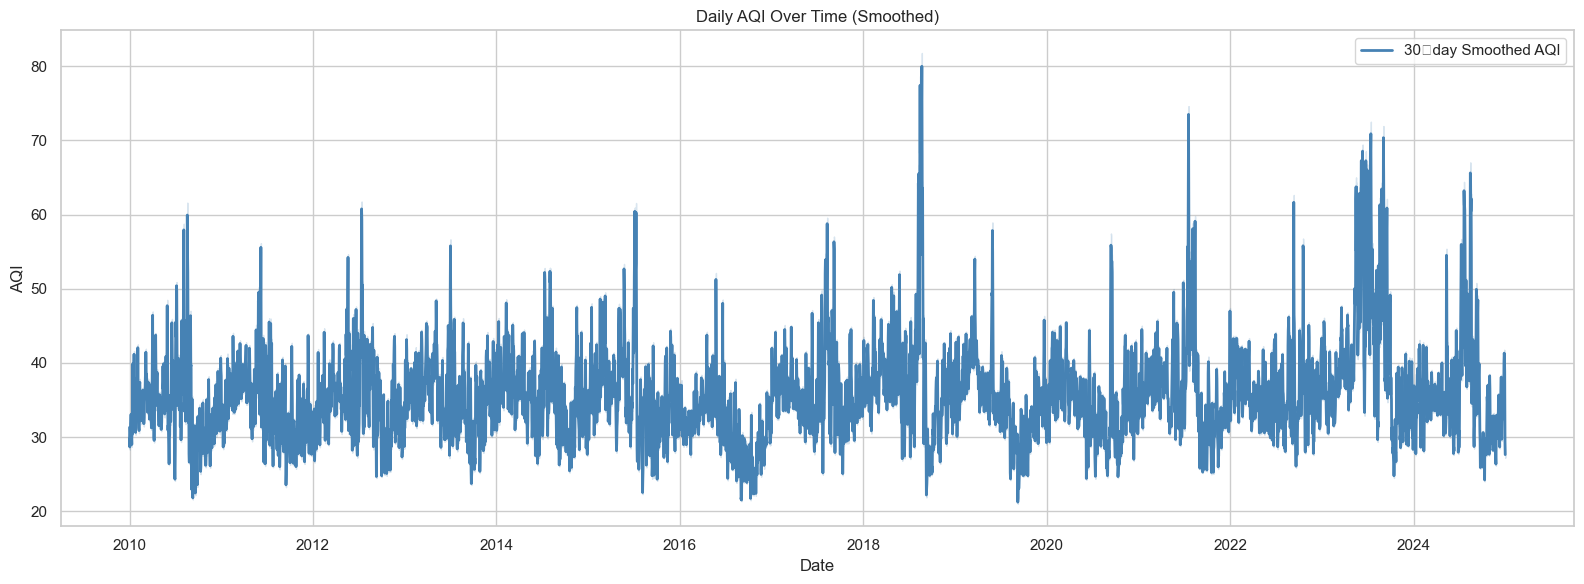

In [72]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = station_daily_aqi.copy()
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

df["AQI_smooth"] = df["AQI"].rolling(
    window=30,
    center=True,
    min_periods=15
).mean()
sns.set_theme(style="whitegrid")

plt.figure(figsize=(16, 6))

# Smoothed AQI
sns.lineplot(
    data=df,
    x="Date",
    y="AQI_smooth",
    linewidth=2,
    color="steelblue",
    label="30‑day Smoothed AQI"
)

plt.title("Daily AQI Over Time (Smoothed)")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.tight_layout()
plt.show()

## 3️⃣ Color‑coded daily time‑series visualizations (one chart per pollutant)
We’ll build on your earlier visualization, but now:

Each pollutant has its own subplot
Line color reflects EPA AQI color category
Interpretation aligns exactly with the reporting standard

### Prepare daily mean AQI per pollutant (for cleaner plots)

In [75]:
daily_pollutant.head()

,Pollutant,Year,DayOfYear,mean_AQI,AQI_smooth,AQI_Category,AQI_Color
0,CO,2010,1,3.250000,4.125667,Good,green
1,CO,2010,2,3.174603,4.089492,Good,green
2,CO,2010,3,3.793651,4.046544,Good,green
3,CO,2010,4,3.841270,4.070000,Good,green
4,CO,2010,5,4.250000,4.154575,Good,green


In [79]:
all_pollutants_df.head()

,NAPS ID,Date,Pollutant,Year,C,AQI
0,10102,2010-01-01,CO,2010,0.34625,4.0
1,10102,2010-01-02,CO,2010,0.46000,5.0
2,10102,2010-01-03,CO,2010,0.29500,3.0
3,10102,2010-01-04,CO,2010,0.23125,3.0
4,10102,2010-01-05,CO,2010,0.28000,3.0


In [80]:
daily_pollutant = (
    all_pollutants_df.groupby(["Date", "Pollutant"], as_index=False)
    .agg(mean_AQI=("AQI", "mean"))
)

daily_pollutant[["AQI_Category", "AQI_Color"]] = (
    daily_pollutant["mean_AQI"].apply(aqi_category_color)
)

##  EPA‑colored multi‑panel visualization

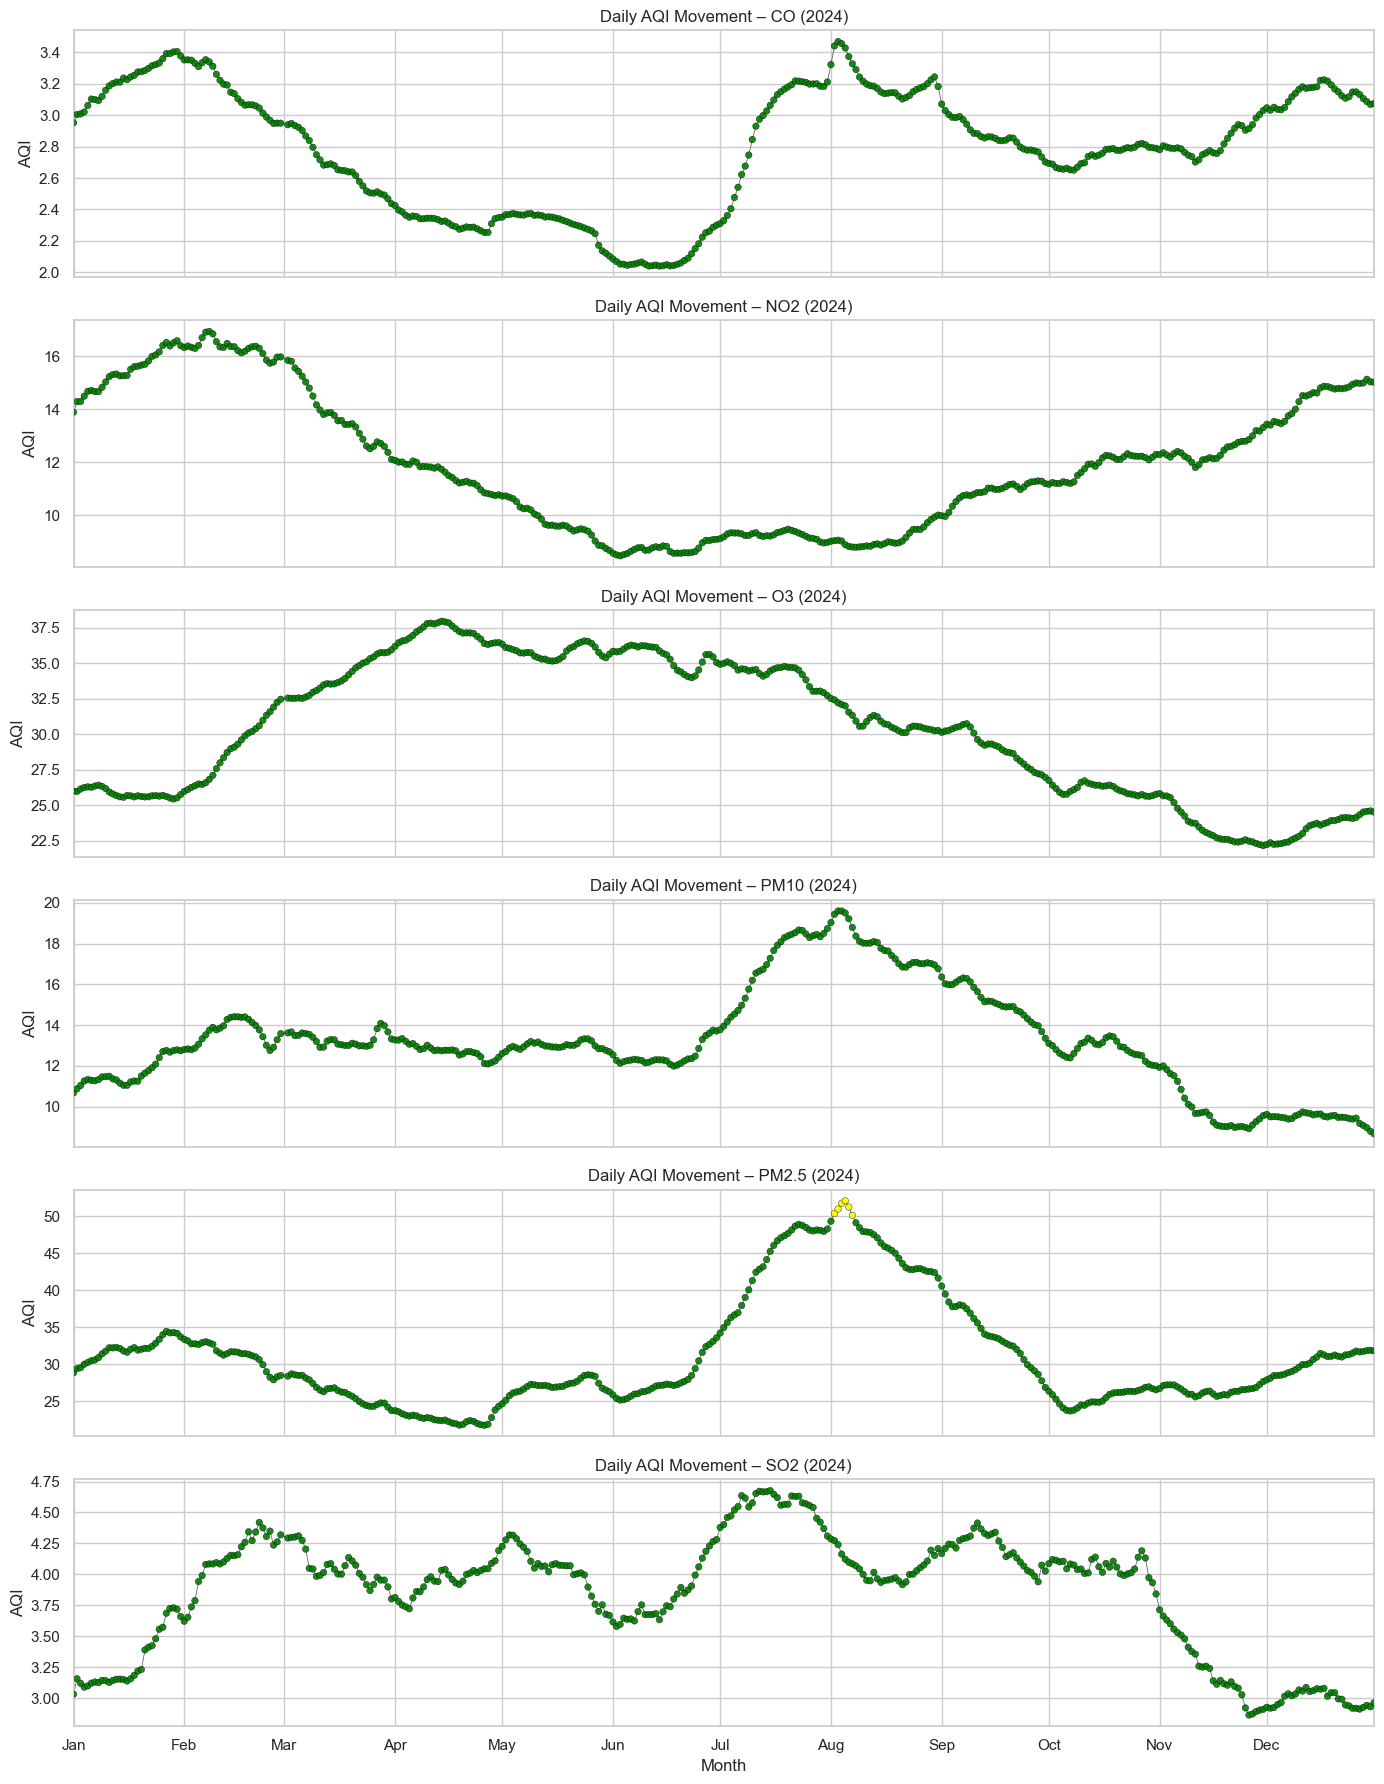

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

pollutants = sorted(df_2024["Pollutant"].unique())

fig, axes = plt.subplots(
    nrows=len(pollutants),
    ncols=1,
    figsize=(14, 3 * len(pollutants)),
    sharex=True
)

if len(pollutants) == 1:
    axes = [axes]

for ax, pol in zip(axes, pollutants):
    sub = df_2024[df_2024["Pollutant"] == pol]

    # Scatter points colored by AQI category ✅
    ax.scatter(
        sub["DayOfYear"],
        sub["AQI_smooth"],
        c=sub["AQI_Color"],
        s=22,
        edgecolors="black",
        linewidths=0.3,
        alpha=0.9,
        zorder=3
    )

    # Thin black connecting line ✅
    ax.plot(
        sub["DayOfYear"],
        sub["AQI_smooth"],
        color="black",
        linewidth=0.6,
        alpha=0.6,
        zorder=2
    )

    ax.set_title(f"Daily AQI Movement – {pol} (2024)")
    ax.set_ylabel("AQI")
    ax.set_xlim(1, 365)

    ax.set_xticks(month_starts)
    ax.set_xticklabels(month_labels)

axes[-1].set_xlabel("Month")
plt.tight_layout()
plt.show()

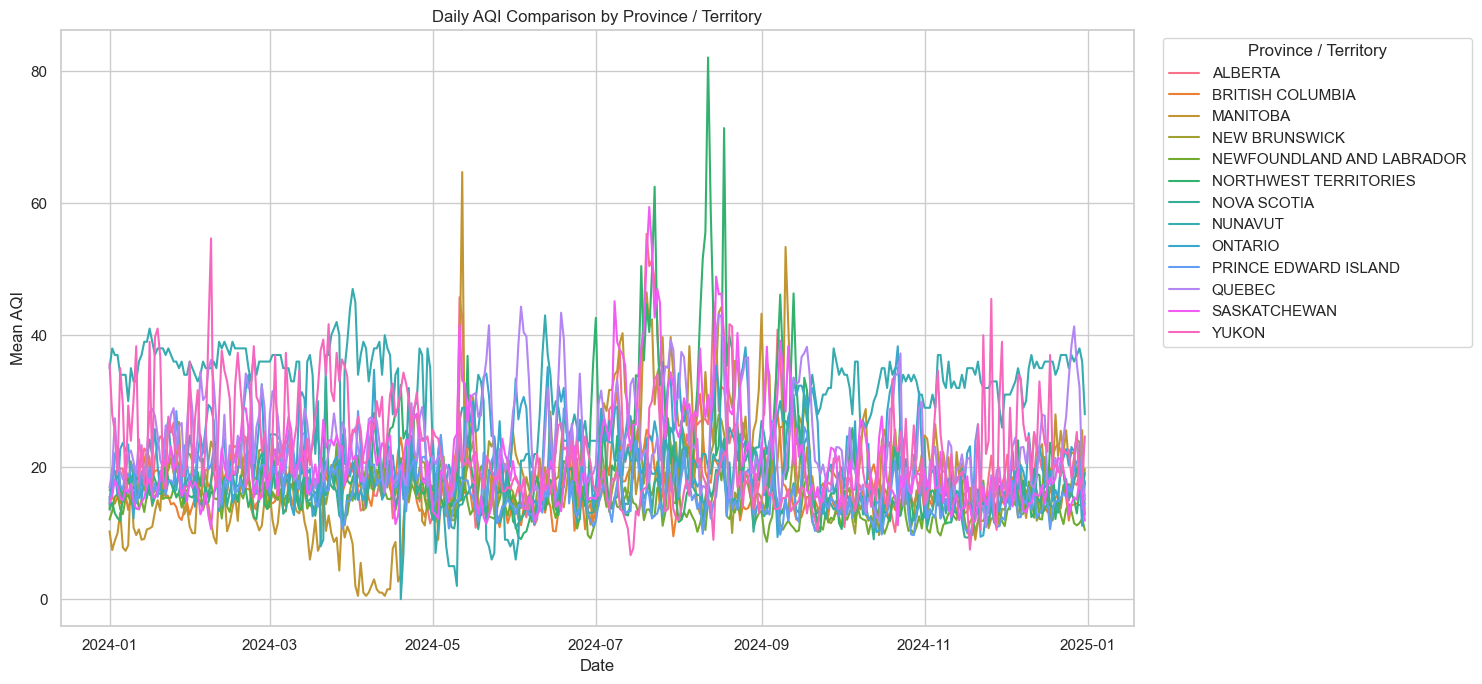

In [77]:
station_daily_province = (
    aqi_daily
    .groupby(["Datetime", "Province/Territory"], as_index=False)
    .agg(mean_AQI=("AQI", "mean"))
)

plt.figure(figsize=(15, 7))

sns.lineplot(
    data=daily_province,
    x="Datetime",
    y="mean_AQI",
    hue="Province/Territory"
)

plt.title("Daily AQI Comparison by Province / Territory")
plt.xlabel("Date")
plt.ylabel("Mean AQI")
plt.legend(
    title="Province / Territory",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

## 3️⃣ Monthly AQI distribution by Province / Territory (boxplots)

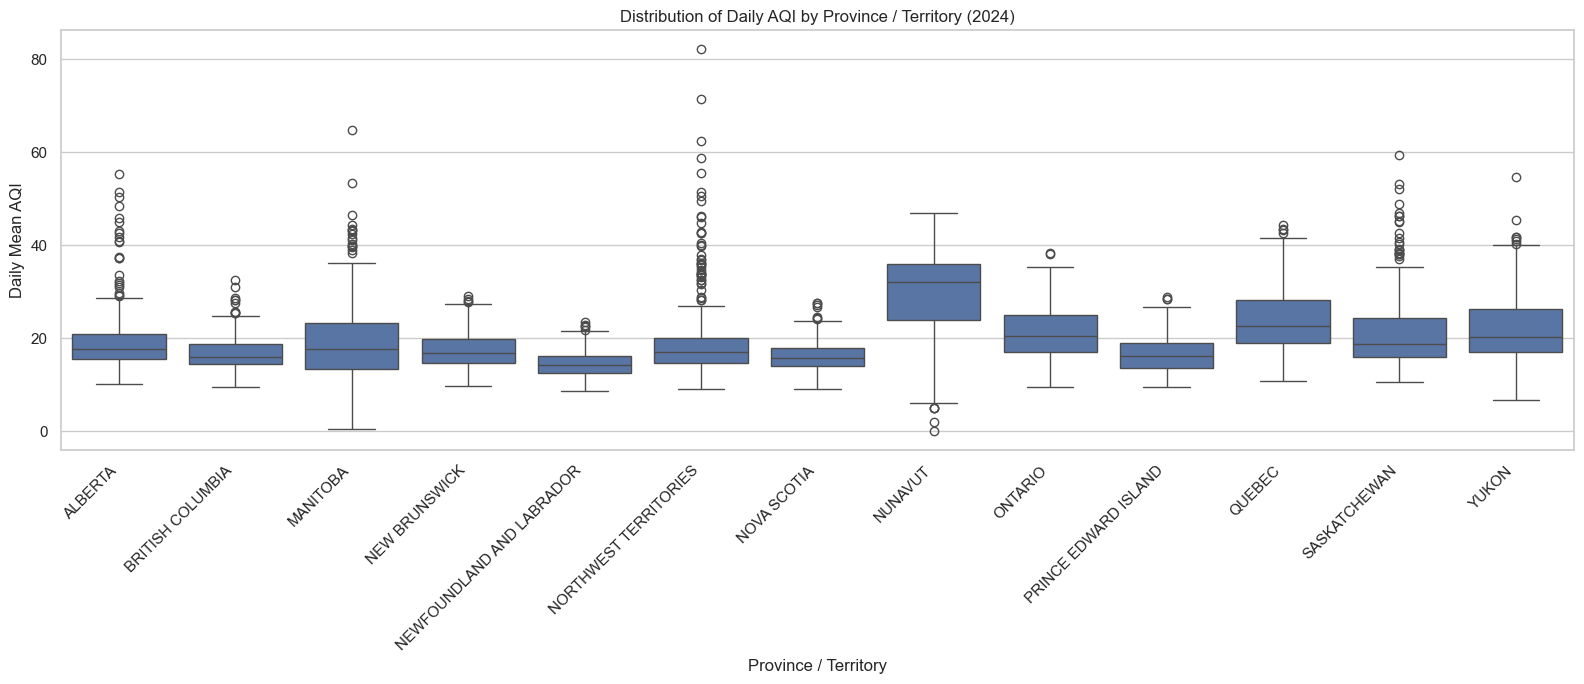

In [79]:
daily_province["Month"] = daily_province["Datetime"].dt.to_period("M").astype(str)

plt.figure(figsize=(16, 7))
sns.boxplot(
    data=daily_province,
    x="Province/Territory",
    y="mean_AQI"
)

plt.title("Distribution of Daily AQI by Province / Territory (2024)")
plt.xlabel("Province / Territory")
plt.ylabel("Daily Mean AQI")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 4️⃣ Heatmap: AQI over time by Province / Territory

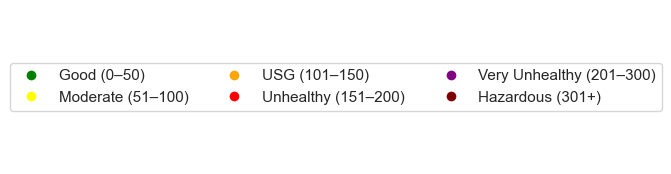

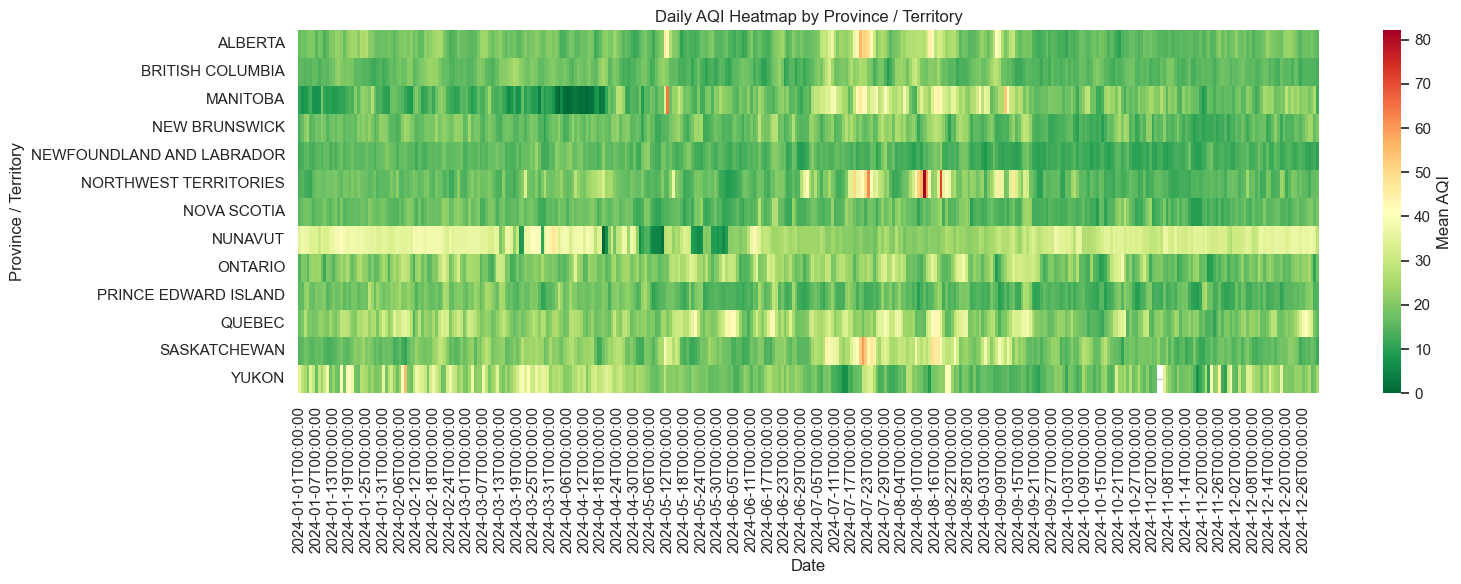

In [82]:
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Good (0–50)', markerfacecolor='green', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Moderate (51–100)', markerfacecolor='yellow', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='USG (101–150)', markerfacecolor='orange', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Unhealthy (151–200)', markerfacecolor='red', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Very Unhealthy (201–300)', markerfacecolor='purple', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Hazardous (301+)', markerfacecolor='maroon', markersize=8),
]

plt.figure(figsize=(8, 2))
plt.legend(handles=legend_elements, loc="center", ncol=3)
plt.axis("off")
plt.show()

heatmap_data = (
    daily_province
    .pivot_table(
        index="Province/Territory",
        columns="Datetime",
        values="mean_AQI"
    )
)

plt.figure(figsize=(16, 6))
sns.heatmap(
    heatmap_data,
    cmap="RdYlGn_r",
    cbar_kws={"label": "Mean AQI"}
)

plt.title("Daily AQI Heatmap by Province / Territory")
plt.xlabel("Date")
plt.ylabel("Province / Territory")
plt.tight_layout()
plt.show()


## ✅ STEP 1: Convert daily AQI → monthly AQI by Province/Territory
- We compute monthly mean AQI (one can also use median if want robustness).

In [84]:
# Ensure Datetime is datetime
aqi_daily = aqi_daily.copy()
aqi_daily["Datetime"] = pd.to_datetime(aqi_daily["Datetime"])

# Create Month column
aqi_daily["Month"] = aqi_daily["Datetime"].dt.to_period("M").astype(str)

# Monthly mean AQI by Province / Territory
monthly_province_aqi = (
    aqi_daily
    .groupby(["Month", "Province/Territory"], as_index=False)
    .agg(mean_AQI=("AQI", "mean"))
)

monthly_province_aqi.head()

,Month,Province/Territory,mean_AQI
0,2024-01,ALBERTA,19.973615
1,2024-01,BRITISH COLUMBIA,16.040846
2,2024-01,MANITOBA,13.532710
3,2024-01,NEW BRUNSWICK,18.223660
4,2024-01,NEWFOUNDLAND AND LABRADOR,15.228484


## ✅ STEP 2: Monthly AQI comparison (clear visualization)
🔹 Option A: Line plot (trend comparison)

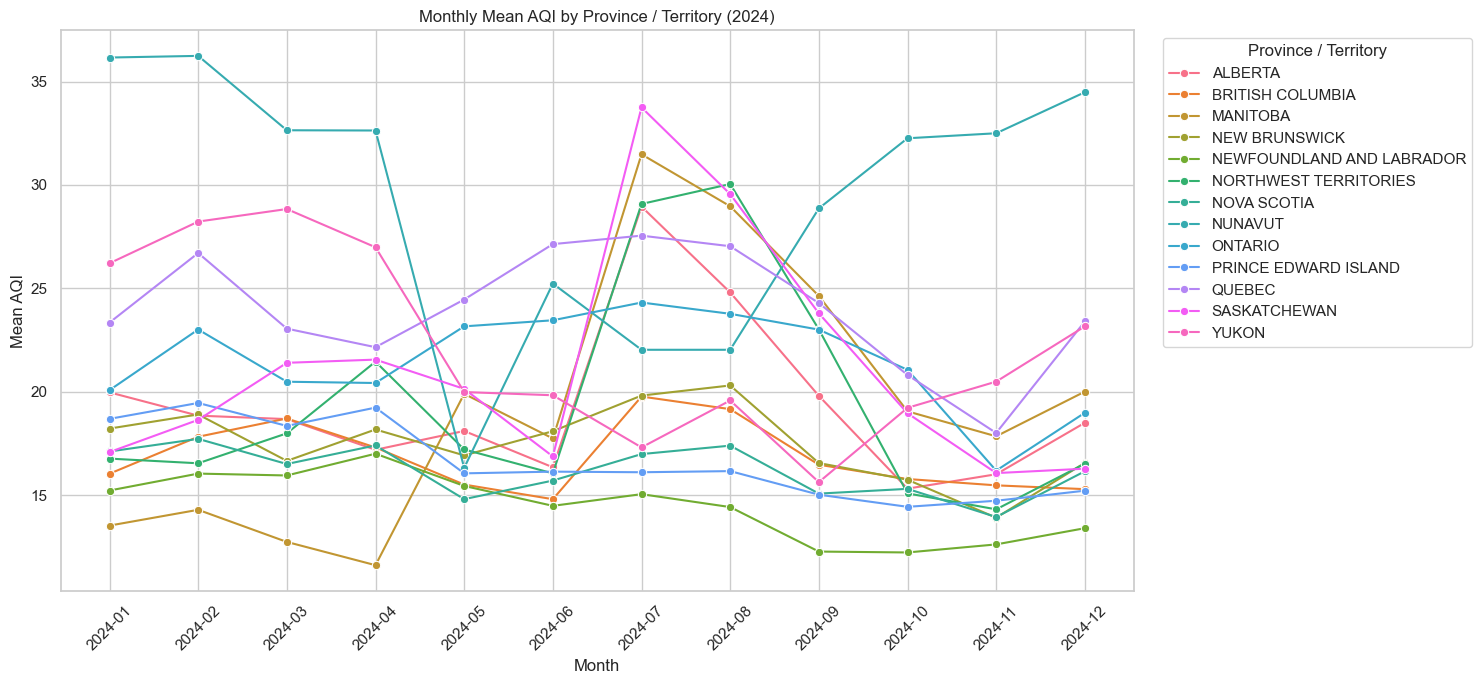

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(15, 7))

sns.lineplot(
    data=monthly_province_aqi,
    x="Month",
    y="mean_AQI",
    hue="Province/Territory",
    marker="o"
)

plt.title("Monthly Mean AQI by Province / Territory (2024)")
plt.xlabel("Month")
plt.ylabel("Mean AQI")
plt.xticks(rotation=45)
plt.legend(
    title="Province / Territory",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

## 🔹 Option B (RECOMMENDED): Monthly AQI bar chart
This makes “which province is higher” very obvious.

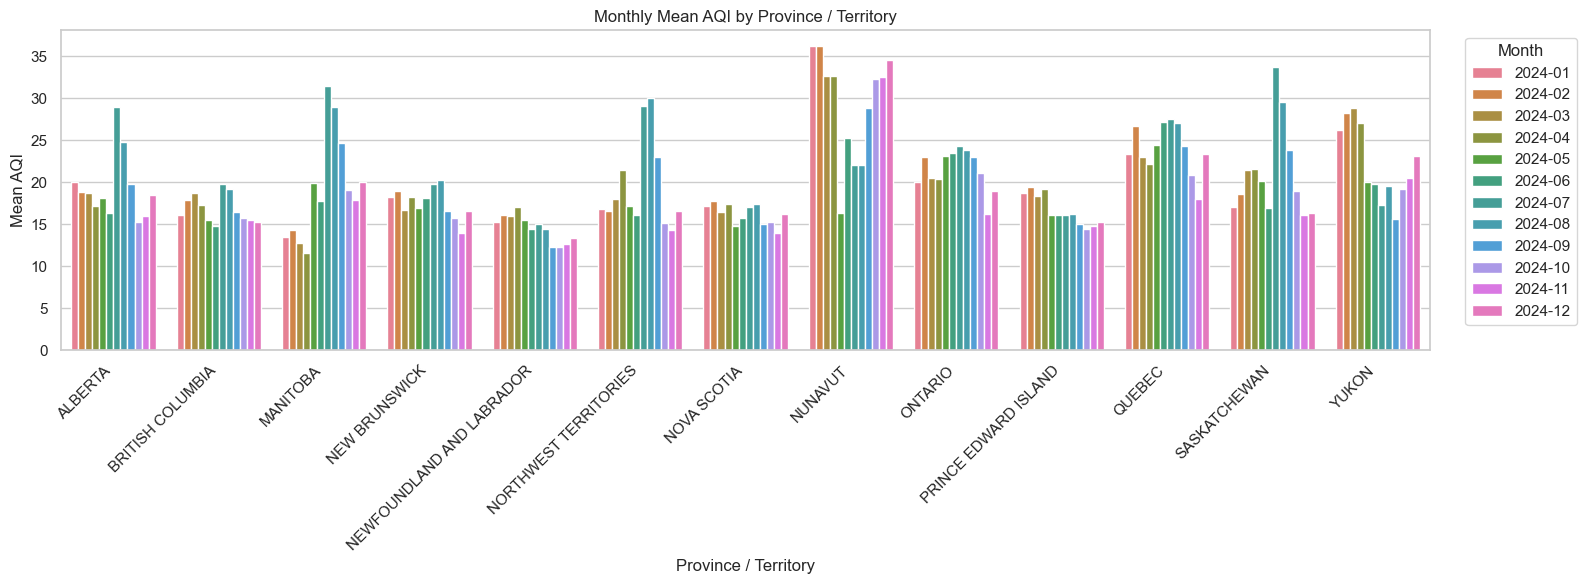

In [86]:
plt.figure(figsize=(16, 6))

sns.barplot(
    data=monthly_province_aqi,
    x="Province/Territory",
    y="mean_AQI",
    hue="Month"
)

plt.title("Monthly Mean AQI by Province / Territory")
plt.xlabel("Province / Territory")
plt.ylabel("Mean AQI")
plt.xticks(rotation=45, ha="right")
plt.legend(
    title="Month",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

## ✅ STEP 3: Identify which province has higher AQI (NUMERIC ANSWER)
✅ A. Overall (entire year)

In [87]:
province_rank = (
    aqi_daily
    .groupby("Province/Territory", as_index=False)
    .agg(
        annual_mean_AQI=("AQI", "mean"),
        max_AQI=("AQI", "max"),
        unhealthy_days=("AQI", lambda x: (x > 100).sum())
    )
    .sort_values("annual_mean_AQI", ascending=False)
)

province_rank

,Province/Territory,annual_mean_AQI,max_AQI,unhealthy_days
7,NUNAVUT,29.240437,47.0,0
10,QUEBEC,23.966686,188.0,62
12,YUKON,22.122316,113.0,1
8,ONTARIO,21.490296,127.0,23
11,SASKATCHEWAN,21.218044,422.0,121
2,MANITOBA,20.818734,196.0,34
5,NORTHWEST TERRITORIES,19.649652,484.0,56
0,ALBERTA,19.398385,426.0,775
3,NEW BRUNSWICK,17.493549,123.0,7
1,BRITISH COLUMBIA,16.847618,488.0,102


## ✅ B. Worst province per month

worst_by_month = (
    monthly_province_aqi
    .sort_values("mean_AQI", ascending=False)
    .groupby("Month")
    .first()
    .reset_index()
)

worst_by_month

In [90]:
worst_by_month = (
    monthly_province_aqi
    .sort_values("mean_AQI", ascending=False)
    .groupby("Month")
    .first()
    .reset_index()
)

worst_by_month

,Month,Province/Territory,mean_AQI
0,2024-01,NUNAVUT,36.161290
1,2024-02,NUNAVUT,36.241379
2,2024-03,NUNAVUT,32.645161
3,2024-04,NUNAVUT,32.633333
4,2024-05,QUEBEC,24.462590
5,2024-06,QUEBEC,27.140768
6,2024-07,SASKATCHEWAN,33.750233
7,2024-08,NORTHWEST TERRITORIES,30.045064
8,2024-09,NUNAVUT,28.866667
9,2024-10,NUNAVUT,32.258065


## ✅ STEP 4: Simple “winner” chart (most impacted provinces)

C:\Users\biauser\AppData\Local\Temp\ipykernel_13404\3161228162.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


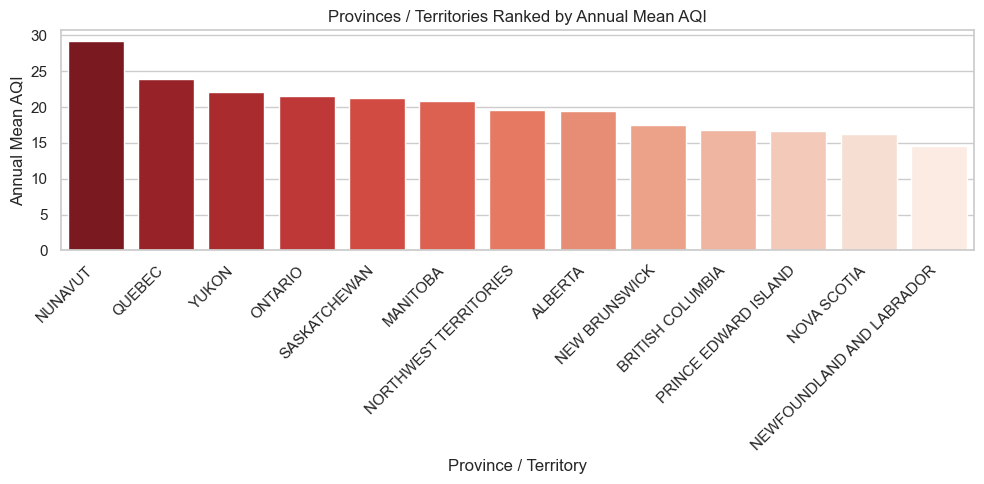

In [91]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=province_rank,
    x="Province/Territory",
    y="annual_mean_AQI",
    palette="Reds_r"
)

plt.title("Provinces / Territories Ranked by Annual Mean AQI")
plt.xlabel("Province / Territory")
plt.ylabel("Annual Mean AQI")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 1️⃣ Ranking chart: Which province has higher AQI overall?

✅ Horizontal bar chart (BEST for ranking)

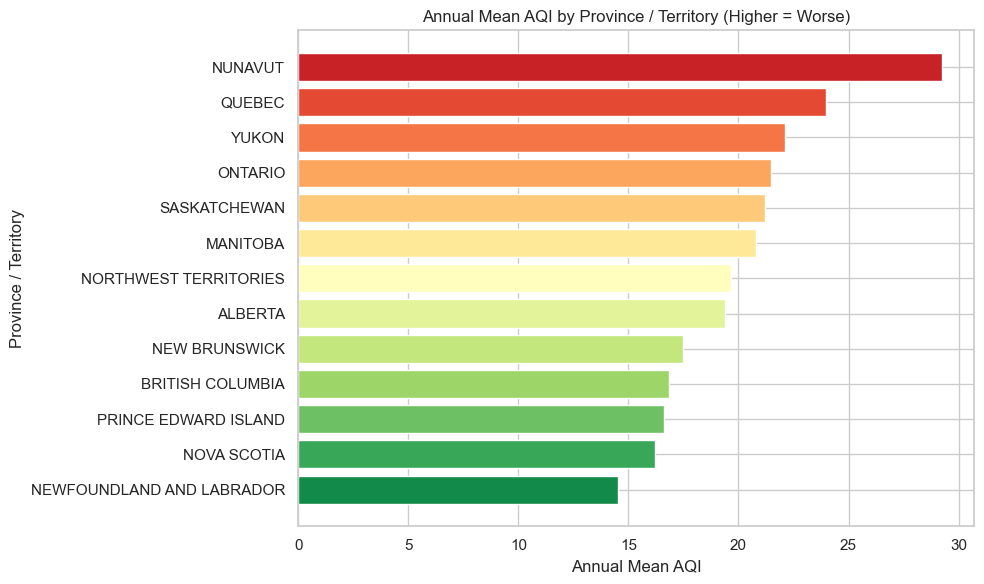

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

province_rank_sorted = province_rank.sort_values("annual_mean_AQI")


palette = sns.color_palette(
    "RdYlGn_r",      # green → yellow → red
    n_colors=len(province_rank_sorted)
)

plt.figure(figsize=(10, 6))


plt.barh(
    province_rank_sorted["Province/Territory"],
    province_rank_sorted["annual_mean_AQI"],
    color=palette
)

plt.title("Annual Mean AQI by Province / Territory (Higher = Worse)")
plt.xlabel("Annual Mean AQI")
plt.ylabel("Province / Territory")
plt.tight_layout()
plt.show()


## 2️⃣ Frequency vs severity: Are problems frequent or extreme?
This plot shows how provinces differ in risk style.
✅ Bubble chart (advanced but very informative)

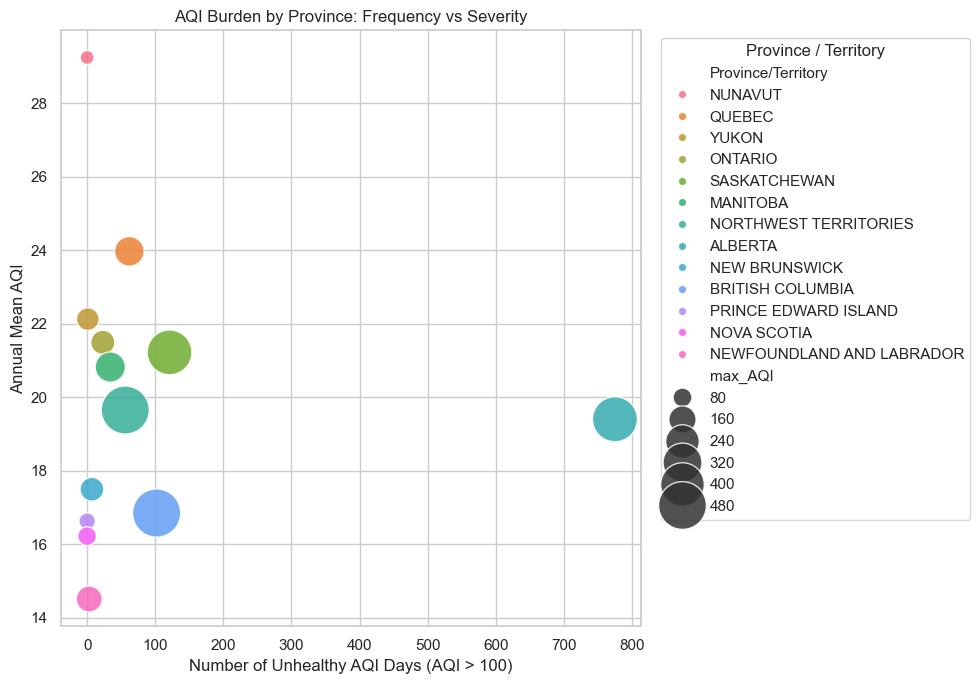

In [94]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=province_rank,
    x="unhealthy_days",
    y="annual_mean_AQI",
    size="max_AQI",
    sizes=(100, 1200),
    hue="Province/Territory",
    alpha=0.85
)

plt.title("AQI Burden by Province: Frequency vs Severity")
plt.xlabel("Number of Unhealthy AQI Days (AQI > 100)")
plt.ylabel("Annual Mean AQI")
plt.legend(
    title="Province / Territory",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

## 3️⃣ Heatmap‑style comparison: Which provinces are consistently worse?
This compresses all information into one visual.
✅ Normalize metrics and show comparison


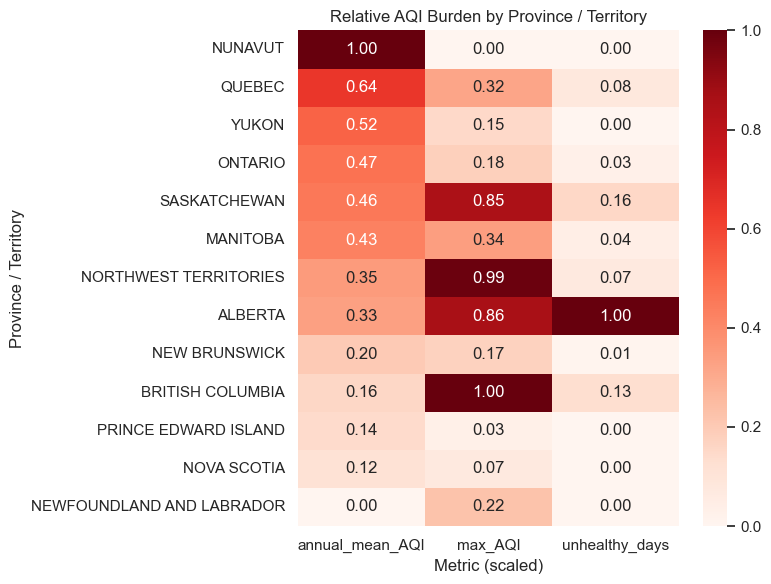

In [95]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

metrics = province_rank.set_index("Province/Territory")[[
    "annual_mean_AQI", "max_AQI", "unhealthy_days"
]]

scaler = MinMaxScaler()
metrics_scaled = pd.DataFrame(
    scaler.fit_transform(metrics),
    index=metrics.index,
    columns=metrics.columns
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    metrics_scaled,
    cmap="Reds",
    annot=True,
    fmt=".2f"
)

plt.title("Relative AQI Burden by Province / Territory")
plt.xlabel("Metric (scaled)")
plt.ylabel("Province / Territory")
plt.tight_layout()
plt.show()